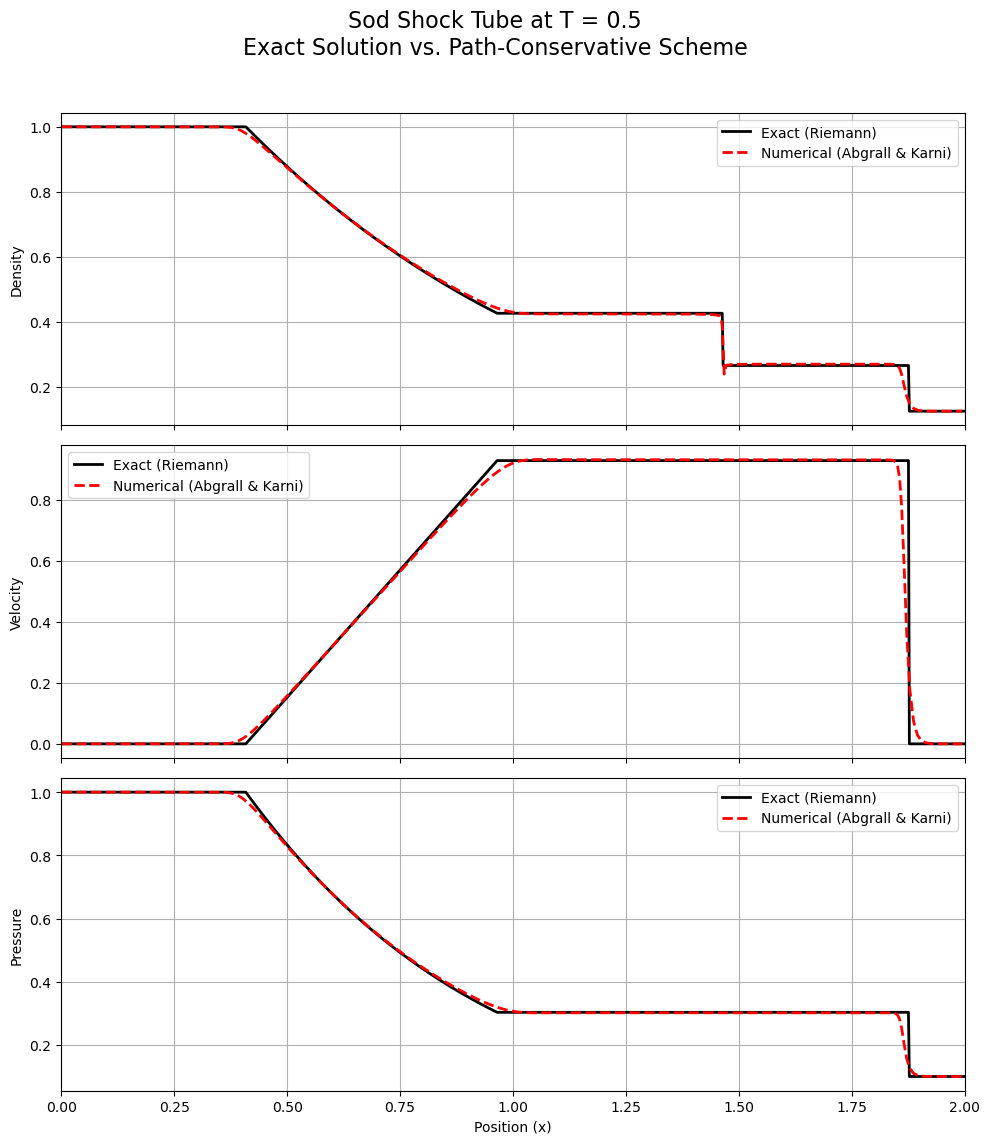

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# 1. EXACT RIEMANN SOLVER (Ground Truth)
# =============================================================================

def get_f(p, rho_k, p_k, gamma):
    """Evaluates the pressure function and its derivative for a given wave."""
    A = 2.0 / ((gamma + 1.0) * rho_k)
    B = (gamma - 1.0) / (gamma + 1.0) * p_k
    if p > p_k:
        # Shock wave
        f = (p - p_k) * np.sqrt(A / (p + B))
        df = (1.0 - 0.5 * (p - p_k) / (p + B)) * np.sqrt(A / (p + B))
    else:
        # Rarefaction wave
        c_k = np.sqrt(gamma * p_k / rho_k)
        f = 2.0 * c_k / (gamma - 1.0) * ((p / p_k)**((gamma - 1.0) / (2.0 * gamma)) - 1.0)
        df = (1.0 / (rho_k * c_k)) * (p / p_k)**(-(gamma + 1.0) / (2.0 * gamma))
    return f, df

def pressure_function(rho_l, u_l, p_l, rho_r, u_r, p_r, gamma=1.4):
    """Newton-Raphson solver to find exact p_star and u_star."""
    p_old = 0.5 * (p_l + p_r) # Initial guess
    tol = 1e-6
    for _ in range(100):
        f_l, df_l = get_f(p_old, rho_l, p_l, gamma)
        f_r, df_r = get_f(p_old, rho_r, p_r, gamma)
        f = f_l + f_r + u_r - u_l
        df = df_l + df_r
        p_new = p_old - f / df
        if abs(p_new - p_old) / (0.5 * (p_new + p_old)) < tol:
            break
        p_old = p_new
        
    p_star = p_new
    f_l, _ = get_f(p_star, rho_l, p_l, gamma)
    u_star = u_l - f_l
    return p_star, u_star

def exact_sod_solution(x_arr, t_val, gamma=1.4):
    """Exact solver for Sod shock tube, aligned with x0=1.0."""
    rho_l, u_l, p_l = 1.0, 0.0, 1.0
    rho_r, u_r, p_r = 0.125, 0.0, 0.1

    if t_val == 0:
        rho = np.where(x_arr < 1.0, rho_l, rho_r)
        u = np.where(x_arr < 1.0, u_l, u_r)
        p = np.where(x_arr < 1.0, p_l, p_r)
        return rho, u, p

    p_star, u_star = pressure_function(rho_l, u_l, p_l, rho_r, u_r, p_r, gamma)
    c_l = np.sqrt(gamma * p_l / rho_l)
    c_r = np.sqrt(gamma * p_r / rho_r)

    rho, u, p = np.zeros_like(x_arr), np.zeros_like(x_arr), np.zeros_like(x_arr)

    for i, xi in enumerate(x_arr):
        s = (xi - 1.0) / t_val  # Aligned to x0 = 1.0

        if s <= u_star:  # Left of contact discontinuity
            if p_star > p_l: # Left Shock
                s_shock = u_l - c_l * np.sqrt((gamma + 1) / (2 * gamma) * p_star / p_l + (gamma - 1) / (2 * gamma))
                if s <= s_shock:
                    rho[i], u[i], p[i] = rho_l, u_l, p_l
                else:
                    rho[i] = rho_l * ((p_star / p_l + (gamma - 1) / (gamma + 1)) / ((gamma - 1) / (gamma + 1) * p_star / p_l + 1))
                    u[i], p[i] = u_star, p_star
            else: # Left Rarefaction
                c_star = c_l * (p_star / p_l)**((gamma - 1) / (2 * gamma))
                s_head, s_tail = u_l - c_l, u_star - c_star
                if s < s_head:
                    rho[i], u[i], p[i] = rho_l, u_l, p_l
                elif s < s_tail:
                    u[i] = (2 / (gamma + 1)) * (c_l + (gamma - 1) / 2 * u_l + s)
                    c = (2 / (gamma + 1)) * (c_l + (gamma - 1) / 2 * (u_l - s))
                    p[i] = p_l * (c / c_l)**(2 * gamma / (gamma - 1))
                    rho[i] = gamma * p[i] / c**2
                else:
                    rho[i] = rho_l * (p_star / p_l)**(1 / gamma)
                    u[i], p[i] = u_star, p_star
        else:  # Right of contact discontinuity
            if p_star > p_r: # Right Shock
                s_shock = u_r + c_r * np.sqrt((gamma + 1) / (2 * gamma) * p_star / p_r + (gamma - 1) / (2 * gamma))
                if s >= s_shock:
                    rho[i], u[i], p[i] = rho_r, u_r, p_r
                else:
                    rho[i] = rho_r * ((p_star / p_r + (gamma - 1) / (gamma + 1)) / ((gamma - 1) / (gamma + 1) * p_star / p_r + 1))
                    u[i], p[i] = u_star, p_star
            else: # Right Rarefaction
                c_star = c_r * (p_star / p_r)**((gamma - 1) / (2 * gamma))
                s_head, s_tail = u_r + c_r, u_star + c_star
                if s > s_head:
                    rho[i], u[i], p[i] = rho_r, u_r, p_r
                elif s > s_tail:
                    u[i] = (2 / (gamma + 1)) * (-c_r + (gamma - 1) / 2 * u_r + s)
                    c = (2 / (gamma + 1)) * (c_r - (gamma - 1) / 2 * (s - u_r))
                    p[i] = p_r * (c / c_r)**(2 * gamma / (gamma - 1))
                    rho[i] = gamma * p[i] / c**2
                else:
                    rho[i] = rho_r * (p_star / p_r)**(1 / gamma)
                    u[i], p[i] = u_star, p_star

    return rho, u, p

# =============================================================================
# 2. NUMERICAL SOLVER (Abgrall & Karni Path-Conservative Scheme)
# =============================================================================

def solve_sod_path_conservative(T=0.5):
    N = 1000
    m_max = 1.125
    dm = m_max / N
    m = np.linspace(dm/2, m_max - dm/2, N)
    
    gamma = 1.4
    v = np.where(m < 1.0, 1.0, 8.0)
    u = np.zeros(N)
    p = np.where(m < 1.0, 1.0, 0.1)
    eps = p * v / (gamma - 1)
    
    W = np.vstack((v, u, eps))
    t = 0.0
    CFL = 0.5
    
    while t < T:
        v, u, eps = W[0, :], W[1, :], W[2, :]
        p = (gamma - 1) * eps / v
        
        C = np.sqrt(gamma * p / v)
        dt = CFL * dm / np.max(C)
        if t + dt > T:
            dt = T - t
            
        v_L, v_R = v[:-1], v[1:]
        u_L, u_R = u[:-1], u[1:]
        p_L, p_R = p[:-1], p[1:]
        
        v_bar, p_bar = 0.5 * (v_L + v_R), 0.5 * (p_L + p_R)
        C_bar = np.sqrt(gamma * p_bar / v_bar)
        
        du, dp = u_R - u_L, p_R - p_L
        
        B1, B2, B3 = -du, dp, p_bar * du
        
        absA_dW_1 = -dp / C_bar
        absA_dW_2 = C_bar * du
        absA_dW_3 = (p_bar / C_bar) * dp
        
        D_minus_1, D_plus_1 = 0.5 * (B1 - absA_dW_1), 0.5 * (B1 + absA_dW_1)
        D_minus_2, D_plus_2 = 0.5 * (B2 - absA_dW_2), 0.5 * (B2 + absA_dW_2)
        D_minus_3, D_plus_3 = 0.5 * (B3 - absA_dW_3), 0.5 * (B3 + absA_dW_3)
        
        W[0, 1:-1] -= (dt / dm) * (D_minus_1[1:] + D_plus_1[:-1])
        W[1, 1:-1] -= (dt / dm) * (D_minus_2[1:] + D_plus_2[:-1])
        W[2, 1:-1] -= (dt / dm) * (D_minus_3[1:] + D_plus_3[:-1])
        
        W[:, 0], W[:, -1] = W[:, 1], W[:, -2]
        t += dt

    v, u, eps = W[0, :], W[1, :], W[2, :]
    p = (gamma - 1) * eps / v
    rho = 1.0 / v
    
    x = np.zeros(N)
    x[0] = v[0] * dm / 2
    for i in range(1, N):
        x[i] = x[i-1] + 0.5 * (v[i-1] + v[i]) * dm
        
    return x, rho, u, p

# =============================================================================
# 3. PLOTTING AND COMPARISON
# =============================================================================

if __name__ == "__main__":
    T_end = 0.5
    
    # Run exact solver
    x_exact = np.linspace(0, 2, 1000)
    rho_ex, u_ex, p_ex = exact_sod_solution(x_exact, T_end)
    
    # Run numerical solver
    x_num, rho_num, u_num, p_num = solve_sod_path_conservative(T_end)
    
    # Plotting
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    fig.suptitle('Sod Shock Tube at T = 0.5\nExact Solution vs. Path-Conservative Scheme', fontsize=16)
    
    variables = [(rho_ex, rho_num, 'Density', axs[0]),
                 (u_ex, u_num, 'Velocity', axs[1]),
                 (p_ex, p_num, 'Pressure', axs[2])]
                 
    for exact, num, title, ax in variables:
        ax.plot(x_exact, exact, 'k-', linewidth=2, label='Exact (Riemann)')
        ax.plot(x_num, num, 'r--', linewidth=2, label='Numerical (Abgrall & Karni)')
        ax.set_ylabel(title)
        ax.grid(True)
        ax.legend()
        ax.set_xlim(0, 2)
        
    axs[2].set_xlabel('Position (x)')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()